# EDA. 
First of all, we need to watch some analysis about our data. 

In [18]:
# Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px

In [19]:
# Paths
DATA_RAW_DIR = Path('../data/raw')
DATA_PROCESSED_DIR = Path('../data/processed')


In [20]:
#Load data raw

df = pd.read_csv(DATA_RAW_DIR / 'cs-training.csv', index_col=0)
df.head(5)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [21]:
column_descriptions = {
    "SeriousDlqin2yrs": "Indicates whether the customer experienced serious delinquency within the next 2 years. 1 = yes, 0 = no.",
    "RevolvingUtilizationOfUnsecuredLines": "Percentage of utilization of unsecured revolving credit lines.",
    "age": "Customer age.",
    "NumberOfTime30-59DaysPastDueNotWorse": "Number of times the customer was 30 to 59 days past due, but not worse.",
    "DebtRatio": "Ratio between debt and monthly income.",
    "MonthlyIncome": "Customer monthly income.",
    "NumberOfOpenCreditLinesAndLoans": "Number of open credit lines and loans.",
    "NumberOfTimes90DaysLate": "Number of times the customer was 90 days or more past due.",
    "NumberRealEstateLoansOrLines": "Number of real estate loans or credit lines.",
    "NumberOfTime60-89DaysPastDueNotWorse": "Number of times the customer was 60 to 89 days past due, but not worse.",
    "NumberOfDependents": "Number of financial dependents of the customer."
}

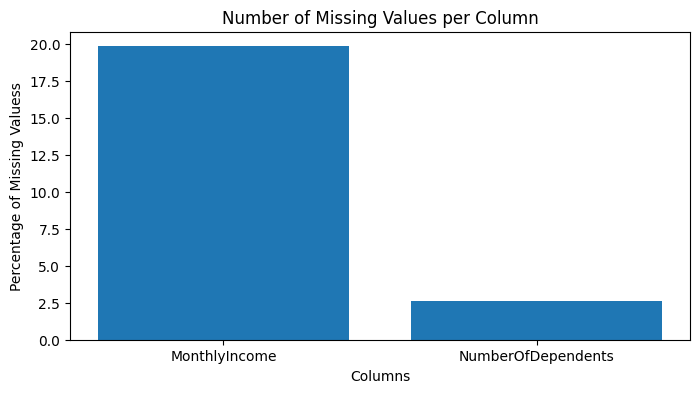

In [22]:
# Missing values

missing_values =  df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values / len(df) * 100

plt.figure(figsize=(8, 4))
plt.bar(missing_values.index, missing_values.values)
plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Valuess')
plt.show()


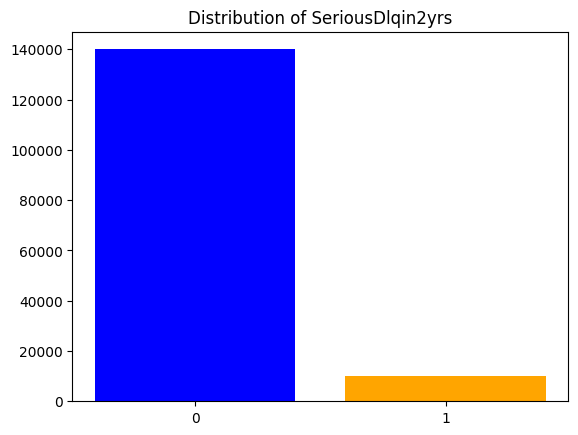

In [23]:
# Review the distribution of the target variable
plt.bar(df['SeriousDlqin2yrs'].value_counts().index, df['SeriousDlqin2yrs'].value_counts().values, color=['blue', 'orange'])
plt.xticks([0,1], ['0', '1'])
plt.title('Distribution of SeriousDlqin2yrs')
plt.show()

## Class imbalance
The target is very imbalanced, so let's quantify exactly how skewed it is.

In [24]:
# Quantify the class imbalance of the target

target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_pct.round(2))
print(f"\nImbalance ratio (negatives per positive): {target_counts[0] / target_counts[1]:.1f} : 1")

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

Imbalance ratio (negatives per positive): 14.0 : 1


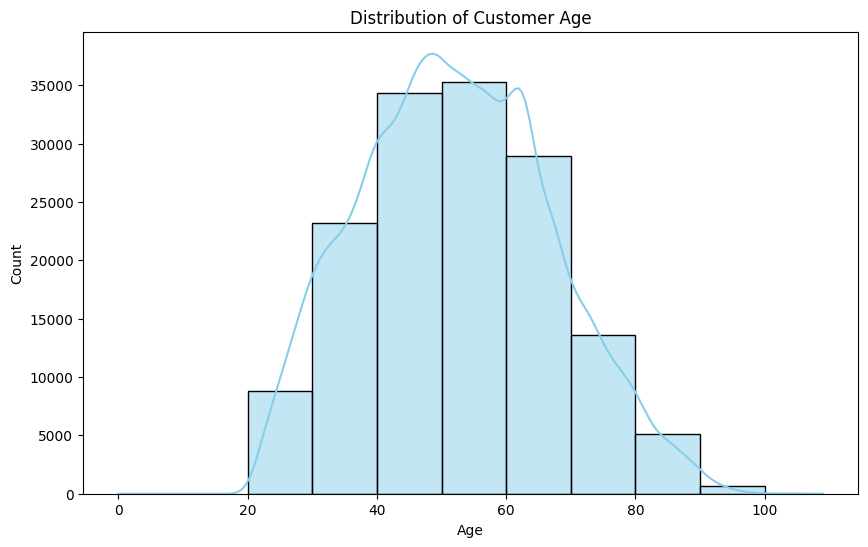

In [25]:
# Let's review the distibution the age of the customers

bin = [20, 30, 40, 50, 60, 70, 80, 90, 100]
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=bin, kde=True, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.show()

## Descriptive statistics
Let's look at the summary statistics to understand the scale and spread of each feature.

In [26]:
# Descriptive statistics for all numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## Outliers in the past-due counters
The past-due counters contain the values 96 and 98, which look like sentinel/placeholder codes rather than real counts.

In [27]:
# The past-due counters contain sentinel values (96 and 98) that are clearly not real counts
pastdue_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

for col in pastdue_cols:
    print(col)
    print(df[col].value_counts().sort_index().tail(6))
    print()

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64



## Distribution of the skewed features
Monetary and ratio features have very long tails, so a log scale makes their shape easier to read.

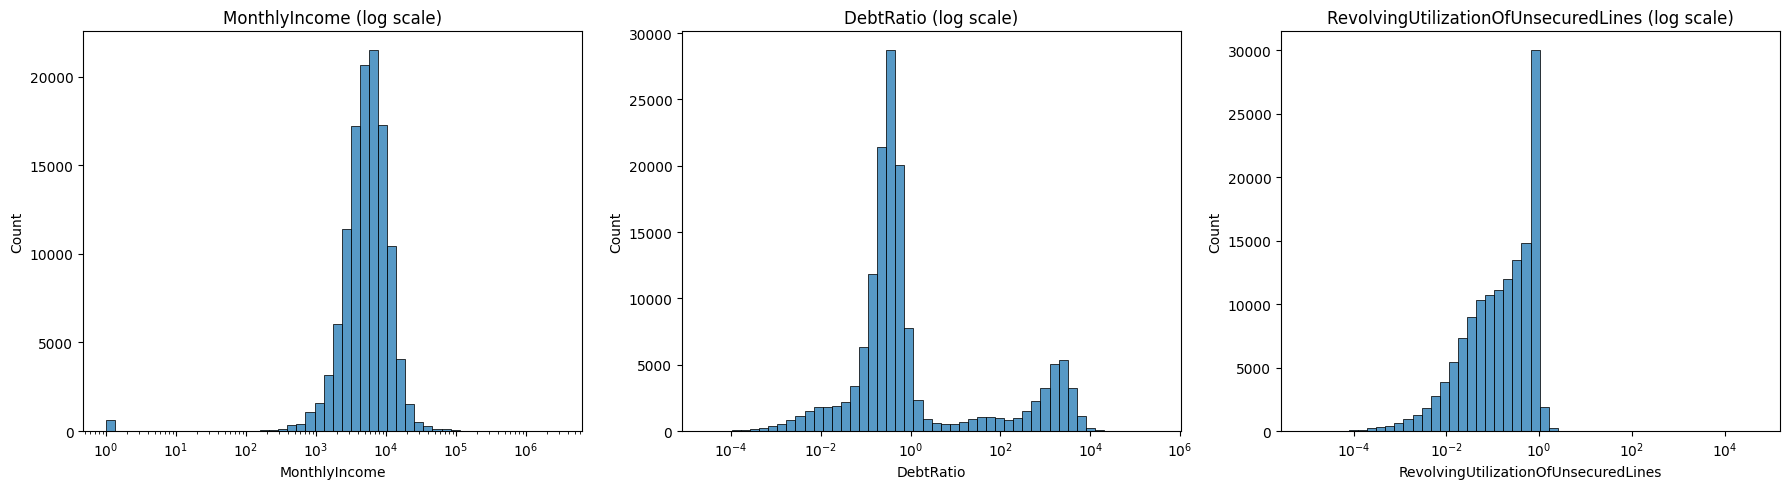

In [28]:
# Monetary / ratio features are heavily right-skewed, so we look at them on a log scale
skewed_cols = ['MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, skewed_cols):
    sns.histplot(df[col].dropna(), bins=50, log_scale=True, ax=ax)
    ax.set_title(f'{col} (log scale)')
plt.tight_layout()
plt.show()

In [29]:
# We can see some outliers in the log scale, especially for MonthlyIncome and DebtRatio. 

income_cols = [
    'MonthlyIncome',
    'DebtRatio',    \
]

for col in income_cols:
    print(f'The lowest 10 values for {col}:')
    display(df.sort_values(col, ascending=True).head(10))
    print(f'The highest 10 values for {col}:')
    display(df.sort_values(col, ascending=False).head(10))

The lowest 10 values for MonthlyIncome:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
147425,0,0.248989,64,0,4053.0,0.0,16,0,2,0,0.0
107396,0,1.000000,46,0,0.0,0.0,1,0,0,0,1.0
116607,0,0.574776,41,0,1436.0,0.0,11,0,0,0,0.0
59680,0,0.200381,23,0,12.0,0.0,3,0,0,0,0.0
146135,0,0.923749,40,3,3122.0,0.0,6,1,2,2,2.0
59695,0,0.194640,43,0,4139.0,0.0,5,0,1,0,3.0
12908,0,0.033814,48,0,2663.0,0.0,13,0,2,0,2.0
28507,0,0.102870,40,0,1953.0,0.0,5,0,1,0,0.0
75479,0,0.095059,63,0,2173.0,0.0,11,0,1,0,0.0
86606,0,1.000000,59,0,1046.0,0.0,2,6,2,0,2.0


The highest 10 values for MonthlyIncome:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
73764,0,0.007328,52,0,0.001470,3008750.0,10,0,1,0,3.0
137141,0,0.000000,68,0,0.002776,1794060.0,15,0,1,0,0.0
111366,0,0.163856,44,0,0.004013,1560100.0,12,0,4,0,2.0
50641,0,0.469025,44,1,0.004537,1072500.0,9,0,2,0,1.0
122544,0,0.041599,55,0,0.000147,835040.0,8,0,0,0,0.0
123292,0,0.226333,67,1,0.005570,730483.0,23,0,1,0,0.0
93565,0,0.071628,50,0,0.008268,702500.0,12,0,4,0,2.0
96550,0,0.064155,52,0,0.003698,699530.0,11,0,2,0,1.0
119137,0,0.151329,49,0,0.001313,649587.0,8,0,0,1,3.0
37079,0,0.000000,83,0,0.000000,629000.0,3,0,0,0,0.0


The lowest 10 values for DebtRatio:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
40776,0,0.0,42,0,0.0,3980.0,4,0,0,0,1.0
56548,0,1.0,52,98,0.0,3700.0,0,98,0,98,0.0
70990,0,1.0,74,0,0.0,3000.0,0,0,0,0,0.0
117364,0,0.0,91,0,0.0,NaN,1,0,0,0,NaN
117362,0,1.0,43,0,0.0,NaN,0,0,0,0,0.0
56541,0,0.0,84,0,0.0,2132.0,4,0,0,0,0.0
42286,0,1.0,56,0,0.0,NaN,0,0,0,0,1.0
71056,0,0.0,27,0,0.0,NaN,2,0,0,0,NaN
71059,0,1.0,34,0,0.0,1200.0,0,2,0,0,0.0
117299,0,0.0,62,0,0.0,2783.0,2,0,0,0,0.0


The highest 10 values for DebtRatio:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
60153,0,0.000000,65,0,329664.0,NaN,9,0,3,0,0.0
36601,0,0.001782,65,0,326442.0,NaN,6,0,1,0,0.0
127048,0,0.034290,58,1,307001.0,NaN,16,0,4,0,2.0
58901,0,0.182640,37,0,220516.0,NaN,8,0,3,0,NaN
4855,0,0.000000,56,0,168835.0,NaN,10,0,3,0,2.0
7514,0,0.152293,71,0,110952.0,NaN,9,0,0,0,0.0
103042,0,0.364845,65,0,106885.0,NaN,8,0,4,0,NaN
69846,0,0.386451,66,0,101320.0,NaN,12,0,0,0,0.0
66786,0,1.000000,63,0,61907.0,NaN,13,0,6,0,0.0
53683,0,1.000000,89,0,61106.5,1.0,2,0,0,0,0.0


In [30]:
skewed_cols = ['MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']

for col in skewed_cols:
    print(col)
    print(df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]))
    print()

MonthlyIncome
count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
1%       0.000000e+00
5%       1.300000e+03
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
95%      1.458760e+04
99%      2.500000e+04
99.9%    7.839575e+04
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

DebtRatio
count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
1%            0.000000
5%            0.004329
25%           0.175074
50%           0.366508
75%           0.868254
95%        2449.000000
99%        4979.040000
99.9%     10613.074000
max      329664.000000
Name: DebtRatio, dtype: float64

RevolvingUtilizationOfUnsecuredLines
count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
1%            0.000000
5%            0.000000
25%           0.029867
50%           0.154181
75%           0.559046
95%           1.000000
99%           1.092956
99.9%      1571.006000
max     

## Correlation between features
Check how the numeric features relate to each other and to the target.

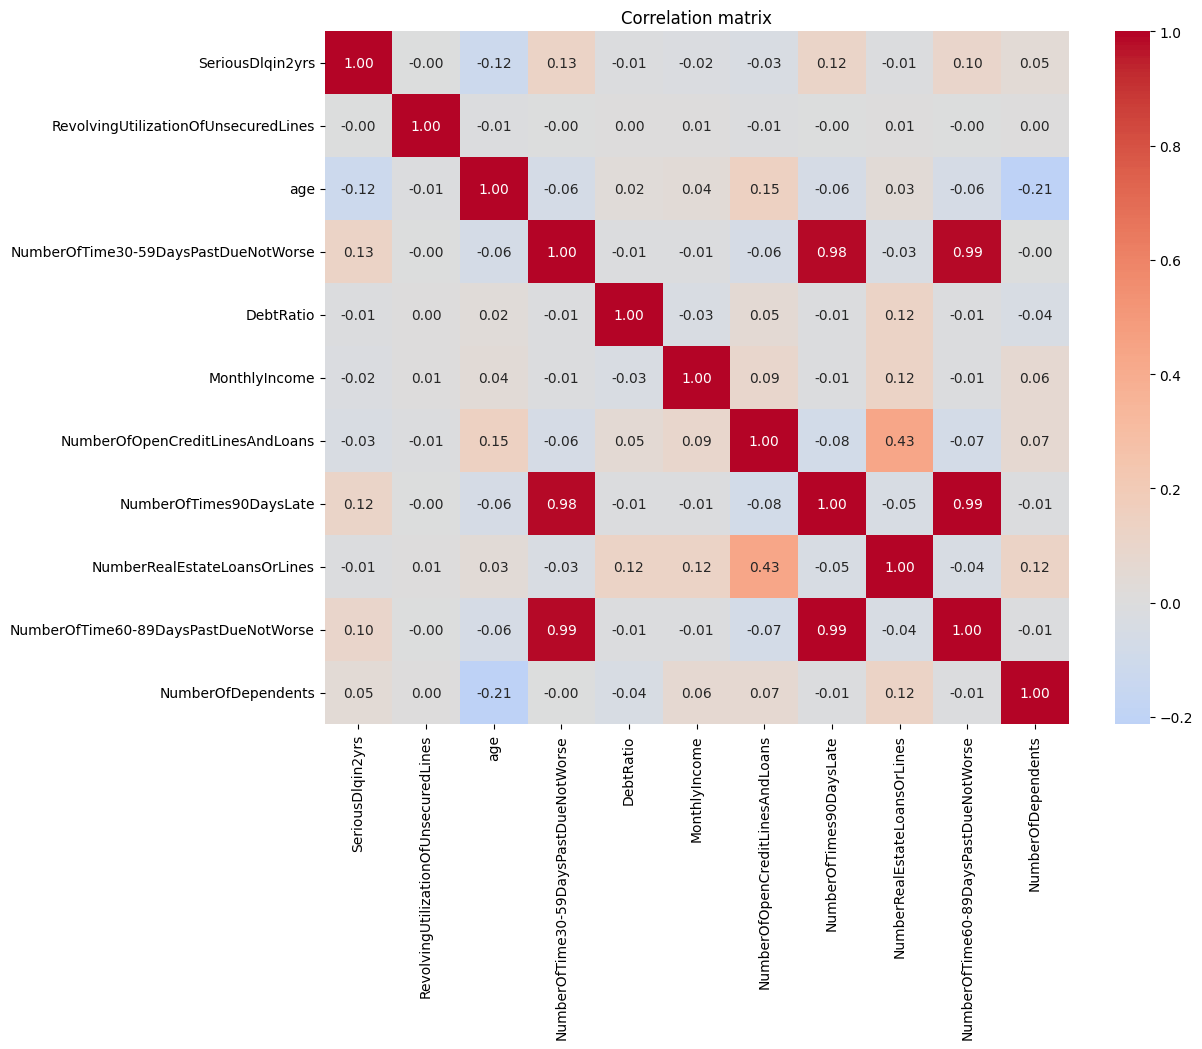

In [31]:
# Correlation between all numeric features
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

## How features relate to default
Finally, let's see how the default rate changes across age groups and past-due history.

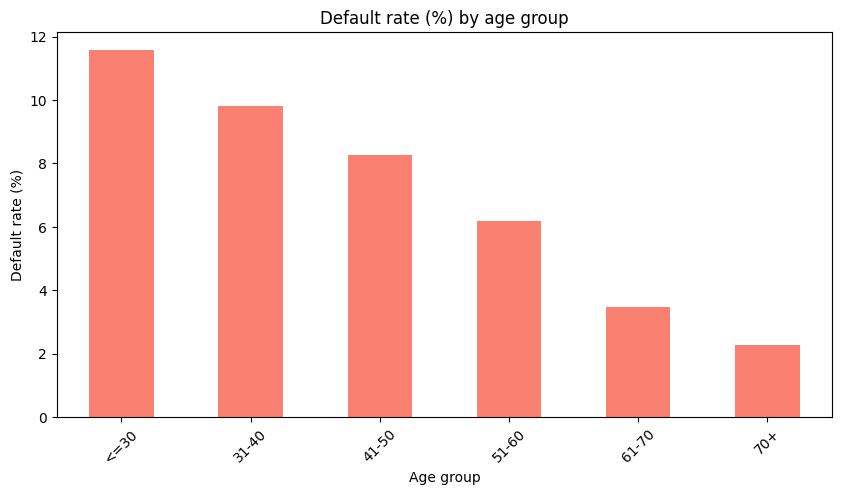

In [32]:
# Default rate by age group: does delinquency vary with age?
df_age = df[df['age'] > 0].copy()

df_age['age_group'] = pd.cut(
    df_age['age'],
    bins=[0, 30, 40, 50, 60, 70, 120],
    labels=['<=30', '31-40', '41-50', '51-60', '61-70', '70+']
)

default_by_age = df_age.groupby('age_group', observed=True)['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(10, 5))
default_by_age.plot(kind='bar', color='salmon')
plt.title('Default rate (%) by age group')
plt.xlabel('Age group')
plt.ylabel('Default rate (%)')
plt.xticks(rotation=45)
plt.show()

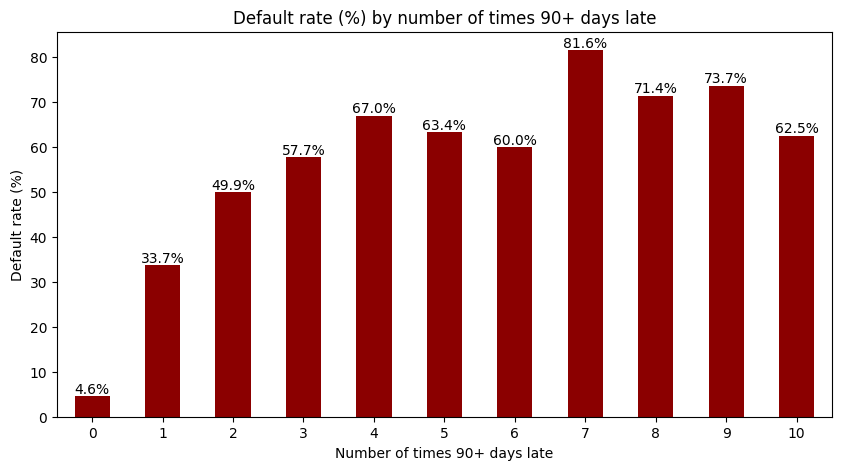

In [33]:
# Default rate by the number of times 90+ days late (capped to ignore the 96/98 sentinels)

mask = df['NumberOfTimes90DaysLate'] <= 10

summary_by_90 = (
    df[mask]
    .groupby('NumberOfTimes90DaysLate')
    .agg(
        n=('SeriousDlqin2yrs', 'size'),
        default_rate=('SeriousDlqin2yrs', 'mean')
    )
)

summary_by_90['default_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))

summary_by_90['default_rate'].plot(kind='bar', ax=ax1, color='darkred')
ax1.set_title('Default rate (%) by number of times 90+ days late')
ax1.set_xlabel('Number of times 90+ days late')
ax1.set_ylabel('Default rate (%)')
ax1.tick_params(axis='x', rotation=0)

for i, value in enumerate(summary_by_90['default_rate']):
    ax1.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.show()

In [34]:
summary_by_90

,n,default_rate
NumberOfTimes90DaysLate,,
0,141662,4.626505
1,5243,33.663933
2,1555,49.903537
3,667,57.721139
4,291,67.010309
5,131,63.358779
6,80,60.000000
7,38,81.578947
8,21,71.428571


The default rate increases sharply when the customer has a history of 90+ days of late payments. The relationship is clearly increasing between 0 and 4 late payments, but for higher values ​​the estimate is less stable because there are very few observations.